In [ ]:
import matplotlib
matplotlib.rcParams['pdf.fonttype'] = 42

import matplotlib.pyplot as plt
import scanpy as sc
import os
import pickle
import pandas as pd
import numpy as np
pd.set_option('future.no_silent_downcasting', True)

color_palette = {}
color_palette['wt'] = 'blue'
color_palette['mutated'] = 'red'
color_palette['heterozygous'] = 'orange'

from picasso import Picasso, CloneTree
from Bio import Phylo
from io import StringIO

import sys
sys.path.append('../../1_figure_CL_proof_of_concept/code/')
import utils_00 as gf_utils
large_data_dir = gf_utils.large_data_dir



In [ ]:
adata_dir = large_data_dir + 'MPN_WTA/MPN_1_BC007_genotyped.h5ad'
adata = sc.read_h5ad(adata_dir)
gf_utils.assign_genotypes(adata)

In [3]:
### find which variants can be confidently called as heterozygous vs only mutated (het+homozygous) vs wt (homozygous)

p_allow_heterozygotes = 0.9
p_disallow_heterozygotes = 0.6

variant_df = adata.obsm['genotype_call'].loc[:,(adata.obsm['genotype_call'].notna() & (adata.obsm['genotype_call'] != 'wt')).sum() > 0]
for mutation in variant_df.columns:
    mask_1 = adata.obsm['genotypes'][[mutation + '_mutated', mutation + '_wt', mutation + '_heterozygous']].max(axis=1) > p_allow_heterozygotes
    mask_2 = adata.obsm['genotypes'][[mutation + '_mutated', mutation + '_wt', mutation + '_heterozygous']].max(axis=1) > p_disallow_heterozygotes
    if (mask_1 == True).sum() > 3000:
        variant_df.loc[~mask_1, mutation] = None
        variant_df.loc[:,mutation] = variant_df[mutation].replace({'mutated': 2, 'wt': 0, 'heterozygous': 1})
    elif (mask_2 == True).sum() > 3000:
        variant_df.loc[~mask_2, mutation] = None
        variant_df.loc[:,mutation] = variant_df[mutation].replace({'mutated': 2, 'wt': 0, 'heterozygous': 2})
    else:
        variant_df = variant_df.drop(columns=[mutation])

variant_df = variant_df.drop('NRAS c.35G>A', axis=1) ### remove NRAS to help resolution for the dominant 4 variants; then we add NRAS later
data = variant_df.dropna().astype(int)
print(len(data))

730


Initialized CloneTree with 5 clones and 730 samples.


/data1/lareauc/users/blattms/miniconda3/envs/gift_paper/lib/python3.11/site-packages/picasso/CloneTree.py:930: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  modal_df = merged_df.groupby(clone_column).agg(self.calc_mode).reset_index()
/data1/lareauc/users/blattms/miniconda3/envs/gift_paper/lib/python3.11/site-packages/picasso/CloneTree.py:933: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  freq_df = merged_df.groupby(clone_column).agg(self.calc_mode_freq).reset_index()
maxp pruned
cmap pruned
kern dropped
post pruned
FFTM dropped
GPOS pruned
GSUB pruned
glyf pruned
Added gid0 to subset
Added first four glyphs t

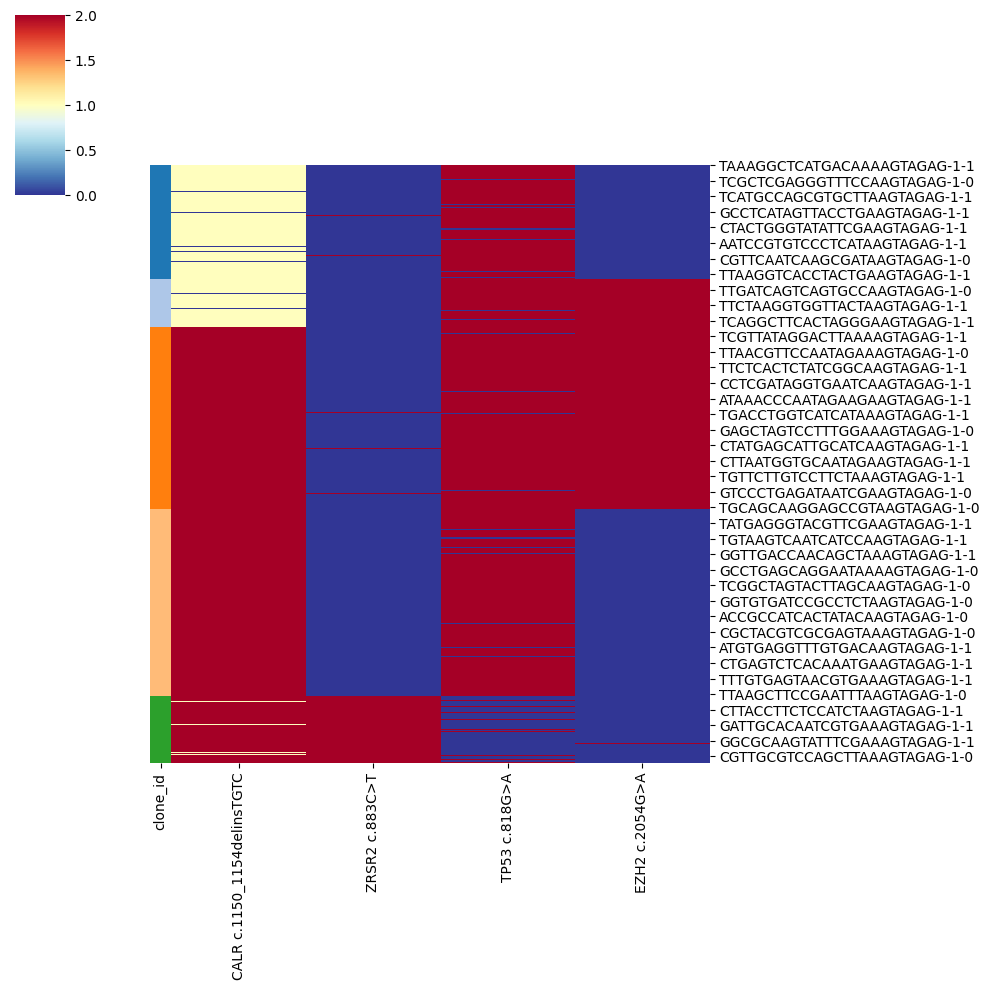

In [4]:
### run picasso, output is not deterministic so load in the saved output 

filename = '../../6_figure_MPN_AML_phylogeny/data/picasso_model.pkl'

model = pickle.load(open(filename, 'rb'))

phylogeny = model.get_phylogeny()
assignments = model.get_clone_assignments()

order = ['1-0-1-0-STOP', '1-0-0-0-STOP', '1-0-0-1-STOP', '1-0-1-1-STOP', '1-1-STOP']
assignments['clone_id'] = pd.Categorical(assignments['clone_id'], categories=order, ordered=True)
assignments = assignments.sort_values('clone_id')

## plot heatmap for supplement
clone_tree = CloneTree(phylogeny, assignments, data)
clone_tree.plot_alterations(cmap='RdYlBu_r', save_as = '../plots/picasso_heatmap.pdf')